# PROJETO -  GRAMMATICAL EVOLUTION


In [ ]:
pip install deap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.0/136.0 kB 4.2 MB/s eta 0:00:00


In [ ]:
!git clone https://github.com/PonyGE/PonyGE2.git

Cloning into 'PonyGE2'...
remote: Enumerating objects: 6262, done.
remote: Counting objects: 100% (22/22), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 6262 (delta 14), reused 9 (delta 9), pack-reused 6240 (from 3)
Receiving objects: 100% (6262/6262), 5.67 MiB | 8.90 MiB/s, done.
Resolving deltas: 100% (4436/4436), done.


In [ ]:
%cd PonyGE2
!pip install -r requirements.txt

/content/PonyGE2


gen	nevals
0  	60    
1  	50    
2  	50    
3  	50    
4  	50    
5  	50    
6  	50    
7  	50    
8  	50    
9  	50    
10 	50    
11 	50    
12 	50    
13 	50    
14 	50    
15 	50    
16 	50    
17 	50    
18 	50    
19 	50    
20 	50    

Melhores critérios evoluídos:

Fórmula S: p*p - np.sqrt(p)
Fitness: (0.9054060271451575, 11.0)

Fórmula S: p*p - np.sqrt(p)
Fitness: (0.9054060271451575, 11.0)

Fórmula S: p*np.log(p+1e-9) + p/(1+p)
Fitness: (0.9054060271451575, 11.0)

Fórmula S: p*p * p/(1+p)
Fitness: (0.9054060271451575, 11.0)

Fórmula S: p*p - np.sqrt(p)
Fitness: (0.9054060271451575, 11.0)

Fórmula S: p*p + p/(1+p)
Fitness: (0.9054060271451575, 11.0)

Fórmula S: np.sqrt(p) * p*p
Fitness: (0.9054060271451575, 11.0)

Fórmula S: p*np.log(p+1e-9) * p
Fitness: (0.9054060271451575, 11.0)

Fórmula S: p*np.log(p+1e-9) + p
Fitness: (0.9054060271451575, 11.0)

Fórmula S: p*p + p*np.log(p+1e-9)
Fitness: (0.9054060271451575, 11.0)

Fórmula S: p*p * p
Fitness: (0.9054060271451575, 11.0)

Fó

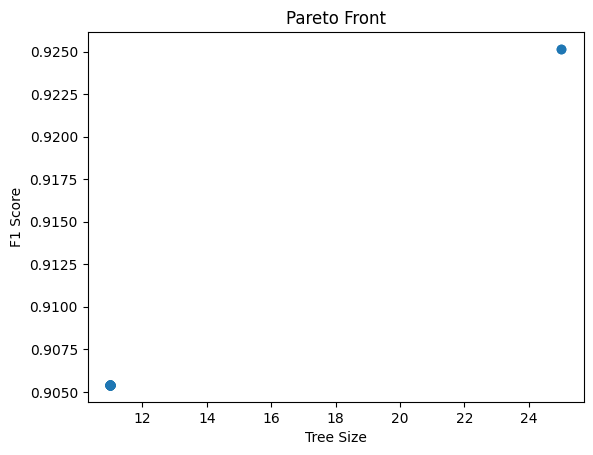


Baseline sklearn F1: 0.945475778809112


In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt

from deap import base, creator, tools, algorithms

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.tree import DecisionTreeClassifier


# =========================================================
# DATASET
# =========================================================

data = load_wine()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

n_classes = len(np.unique(y))


# =========================================================
# GRAMMATICAL EVOLUTION
# =========================================================

GRAMMAR = {

    "base": [
        "p",
        "p*np.log(p+1e-9)",
        "p*p",
        "np.sqrt(p)",
        "p/(1+p)"
    ],

    "combine": [
        "{a} + {b}",
        "{a} - {b}",
        "{a} * {b}"
    ]
}


def genotype_to_formula(genotype):

    expr1 = GRAMMAR["base"][genotype[0] % len(GRAMMAR["base"])]
    expr2 = GRAMMAR["base"][genotype[1] % len(GRAMMAR["base"])]

    comb = GRAMMAR["combine"][genotype[2] % len(GRAMMAR["combine"])]

    formula = comb.format(a=expr1, b=expr2)

    def S(class_counts):

        total = sum(class_counts)

        score = 0

        for count in class_counts:

            if total == 0:
                continue

            p = count / total

            local_vars = {
                "p": p,
                "np": np
            }

            score += eval(formula, {"__builtins__":None}, local_vars)

        return score

    return S, formula


# =========================================================
# TDIDT TREE
# =========================================================

class Node:

    def __init__(self):
        self.feature = None
        self.threshold = None
        self.left = None
        self.right = None
        self.label = None


class DecisionTreeTDIDT:

    def __init__(self, split_function, max_depth=5):
        self.split_function = split_function
        self.max_depth = max_depth
        self.tree_size = 0

    def fit(self, X, y):

        self.tree_size = 0
        self.root = self.build_tree(X, y, 0)

    def build_tree(self, X, y, depth):

        node = Node()
        self.tree_size += 1

        if depth >= self.max_depth or len(np.unique(y)) == 1:

            node.label = np.bincount(y).argmax()
            return node

        best_score = -np.inf
        best_feature = None
        best_thresh = None

        for feature in range(X.shape[1]):

            thresholds = np.unique(X[:, feature])

            for t in thresholds:

                left_idx = X[:, feature] <= t
                right_idx = X[:, feature] > t

                if np.sum(left_idx) == 0 or np.sum(right_idx) == 0:
                    continue

                left_counts = np.bincount(y[left_idx], minlength=n_classes)
                right_counts = np.bincount(y[right_idx], minlength=n_classes)

                score = self.split_function(left_counts) + self.split_function(right_counts)

                if score > best_score:

                    best_score = score
                    best_feature = feature
                    best_thresh = t

        if best_feature is None:

            node.label = np.bincount(y).argmax()
            return node

        node.feature = best_feature
        node.threshold = best_thresh

        left_idx = X[:, best_feature] <= best_thresh
        right_idx = X[:, best_feature] > best_thresh

        node.left = self.build_tree(X[left_idx], y[left_idx], depth + 1)
        node.right = self.build_tree(X[right_idx], y[right_idx], depth + 1)

        return node

    def predict_one(self, x, node):

        if node.label is not None:
            return node.label

        if x[node.feature] <= node.threshold:
            return self.predict_one(x, node.left)
        else:
            return self.predict_one(x, node.right)

    def predict(self, X):

        preds = []

        for x in X:
            preds.append(self.predict_one(x, self.root))

        return np.array(preds)


# =========================================================
# DEAP CONFIG
# =========================================================

creator.create("FitnessMulti", base.Fitness, weights=(1.0, -1.0))
creator.create("Individual", list, fitness=creator.FitnessMulti)

toolbox = base.Toolbox()

toolbox.register("attr_int", random.randint, 0, 50)
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_int, 5)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)


# =========================================================
# FITNESS
# =========================================================

def evaluate(individual):

    split_function, formula = genotype_to_formula(individual)

    tree = DecisionTreeTDIDT(split_function, max_depth=5)

    tree.fit(X_train, y_train)

    preds = tree.predict(X_test)

    f1 = f1_score(y_test, preds, average="macro")

    complexity = tree.tree_size

    return f1, complexity


toolbox.register("evaluate", evaluate)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutUniformInt, low=0, up=50, indpb=0.2)
toolbox.register("select", tools.selNSGA2)


# =========================================================
# EVOLUTION
# =========================================================

pop = toolbox.population(n=60)

algorithms.eaMuPlusLambda(
    pop,
    toolbox,
    mu=60,
    lambda_=50,
    cxpb=0.7,
    mutpb=0.3,
    ngen=20,
    verbose=True
)


# =========================================================
# PARETO FRONT
# =========================================================

front = tools.sortNondominated(pop, len(pop), first_front_only=True)[0]

print("\nMelhores critérios evoluídos:\n")

for ind in front[:20]:

    split_function, formula = genotype_to_formula(ind)

    print("Fórmula S:", formula)
    print("Fitness:", ind.fitness.values)
    print()


# =========================================================
# PLOT PARETO
# =========================================================

f1_vals = [ind.fitness.values[0] for ind in front]
sizes = [ind.fitness.values[1] for ind in front]

plt.scatter(sizes, f1_vals)
plt.xlabel("Tree Size")
plt.ylabel("F1 Score")
plt.title("Pareto Front")
plt.show()


# =========================================================
# BASELINE COMPARISON
# =========================================================

baseline = DecisionTreeClassifier(max_depth=5)
baseline.fit(X_train, y_train)

preds = baseline.predict(X_test)

print("\nBaseline sklearn F1:", f1_score(y_test, preds, average="macro"))